In [ ]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/MU projekat/konacni.csv')

In [ ]:
df.drop('Credit_Score', axis=1, inplace=True)

month_mode = df['Occupation'].mode()[0]
df['Occupation'] = df['Occupation'].fillna(month_mode)

amount_median = df['Amount_invested_monthly'].median()
df['Amount_invested_monthly'] = df['Amount_invested_monthly'].fillna(amount_median)

# Label encoding za sve kategoričke varijable
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

for col in df.select_dtypes(include=['object', 'category']).columns:
    df[col] = encoder.fit_transform(df[col])  # Kodiranje i prepisivanje originalne kolone

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data = scaler.fit_transform(df)

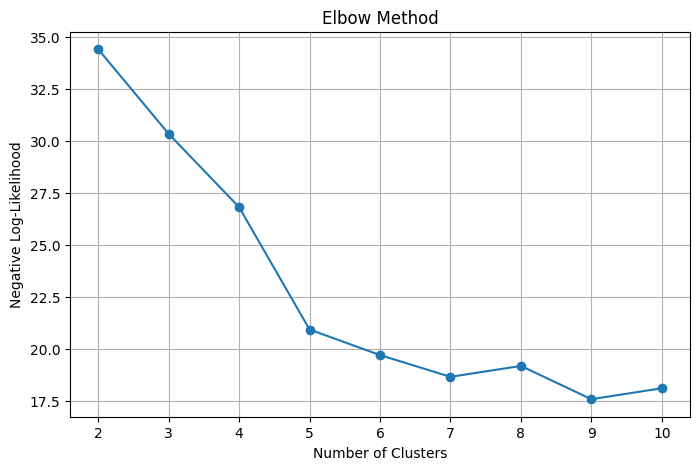

In [ ]:
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

# Range of cluster numbers to test
k_values = range(2, 11)

# Negative log-likelihood as a measure of cost
log_likelihoods = []
for k in k_values:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(data)
    log_likelihoods.append(-gmm.lower_bound_)

# Plot the Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(k_values, log_likelihoods, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Negative Log-Likelihood')
plt.grid()
plt.show()

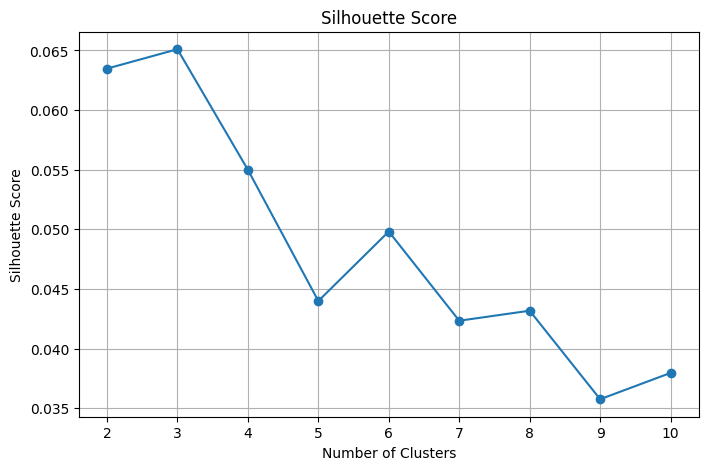

In [ ]:
from sklearn.metrics import silhouette_score

# Silhouette scores for different numbers of clusters
silhouette_scores = []

for k in range(2, 11):  # Start from 2 since silhouette is undefined for 1 cluster
    gmm = GaussianMixture(n_components=k, random_state=42)
    labels = gmm.fit_predict(data)
    score = silhouette_score(data, labels)
    silhouette_scores.append(score)

# Plot the Silhouette Score
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Score')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.grid()
plt.show()

In [ ]:
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

optimal_clusters = 3
gmm = GaussianMixture(n_components=optimal_clusters, random_state=42)
gmm.fit(data)

# Assign each data point to a cluster
cluster_labels = gmm.predict(data)

# Add cluster labels to the original dataset
df['Cluster'] = cluster_labels

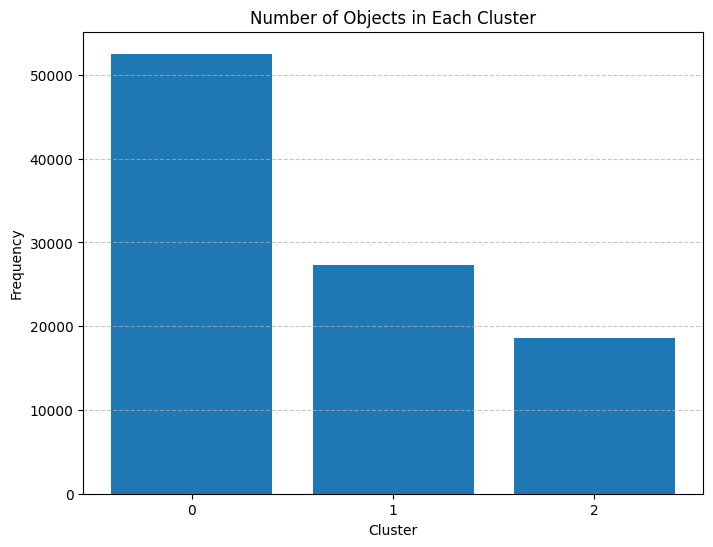

In [ ]:
import matplotlib.pyplot as plt

# Broj objekata u svakom klasteru
cluster_counts = df['Cluster'].value_counts()

# Nacrtaj histogram
plt.figure(figsize=(8, 6))
plt.bar(cluster_counts.index, cluster_counts.values)
plt.title('Number of Objects in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Frequency')
plt.xticks(cluster_counts.index)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Log-vjerovatnoća
log_likelihood = gmm.score(data) * len(data)
print(f"Log-Likelihood: {log_likelihood}")

Log-Likelihood: -2986741.529018833


In [ ]:
# AIC vrijednost
aic = gmm.aic(data)
print(f"AIC: {aic}")

AIC: 5976457.058037666


In [ ]:
# BIC vrijednost
bic = gmm.bic(data)
print(f"BIC: {bic}")

BIC: 5990579.367950262


In [ ]:
print(gmm.n_iter_)

10


In [ ]:
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

optimal_clusters = 5
gmm = GaussianMixture(n_components=optimal_clusters, random_state=42)
gmm.fit(data)

# Assign each data point to a cluster
cluster_labels = gmm.predict(data)

# Add cluster labels to the original dataset
df['Cluster'] = cluster_labels

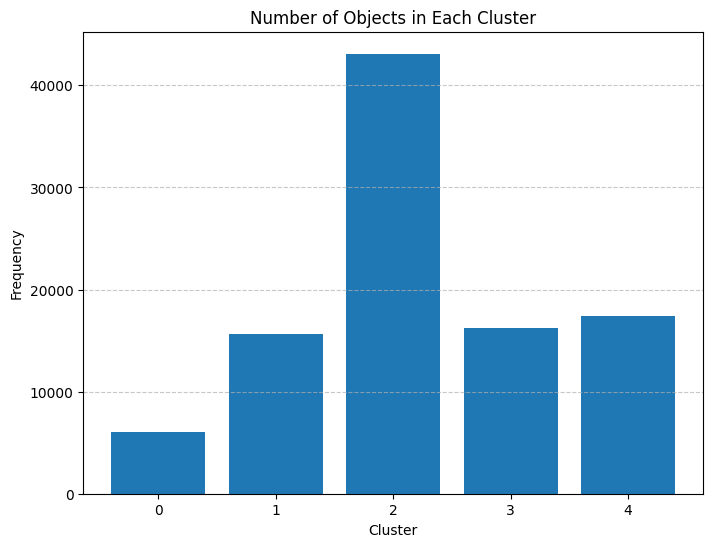

In [ ]:
import matplotlib.pyplot as plt

# Broj objekata u svakom klasteru
cluster_counts = df['Cluster'].value_counts()

# Nacrtaj histogram
plt.figure(figsize=(8, 6))
plt.bar(cluster_counts.index, cluster_counts.values)
plt.title('Number of Objects in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Frequency')
plt.xticks(cluster_counts.index)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Log-vjerovatnoća
log_likelihood = gmm.score(data) * len(data)
print(f"Log-Likelihood: {log_likelihood}")

Log-Likelihood: -2060675.8818781574


In [ ]:
# AIC vrijednost
aic = gmm.aic(data)
print(f"AIC: {aic}")

AIC: 4126309.7637563148


In [ ]:
# BIC vrijednost
bic = gmm.bic(data)
print(f"BIC: {bic}")

BIC: 4149853.278398766


In [ ]:
print(gmm.n_iter_)

37


In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.90)
data_pca = pca.fit_transform(data)

In [ ]:
print(f"Broj zadržanih komponenti: {pca.n_components_}")

Broj zadržanih komponenti: 23


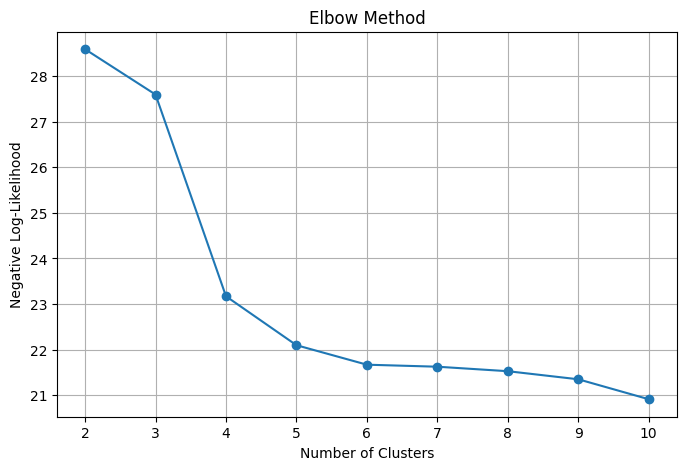

In [ ]:
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

# Range of cluster numbers to test
k_values = range(2, 11)

# Negative log-likelihood as a measure of cost
log_likelihoods = []
for k in k_values:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(data_pca)
    log_likelihoods.append(-gmm.lower_bound_)

# Plot the Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(k_values, log_likelihoods, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Negative Log-Likelihood')
plt.grid()
plt.show()

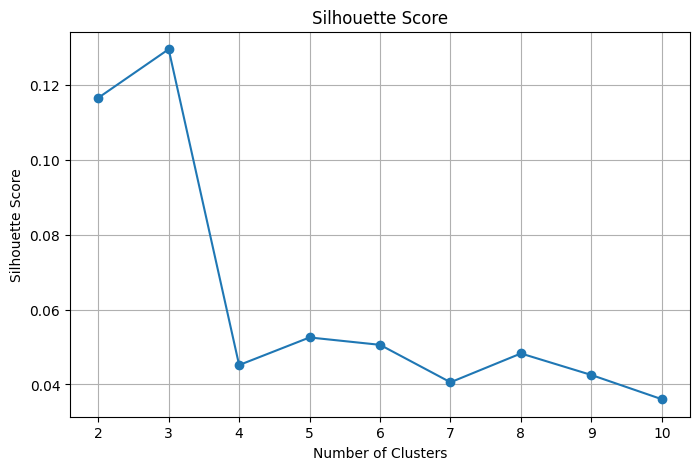

In [ ]:
from sklearn.metrics import silhouette_score

# Silhouette scores for different numbers of clusters
silhouette_scores = []

for k in range(2, 11):  # Start from 2 since silhouette is undefined for 1 cluster
    gmm = GaussianMixture(n_components=k, random_state=42)
    labels = gmm.fit_predict(data_pca)
    score = silhouette_score(data_pca, labels)
    silhouette_scores.append(score)

# Plot the Silhouette Score
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Score')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.grid()
plt.show()

In [ ]:
optimal_clusters = 3
gmm = GaussianMixture(n_components=optimal_clusters, random_state=42)
gmm.fit(data_pca)

# Assign each data point to a cluster
cluster_labels = gmm.predict(data_pca)

df['Cluster'] = cluster_labels

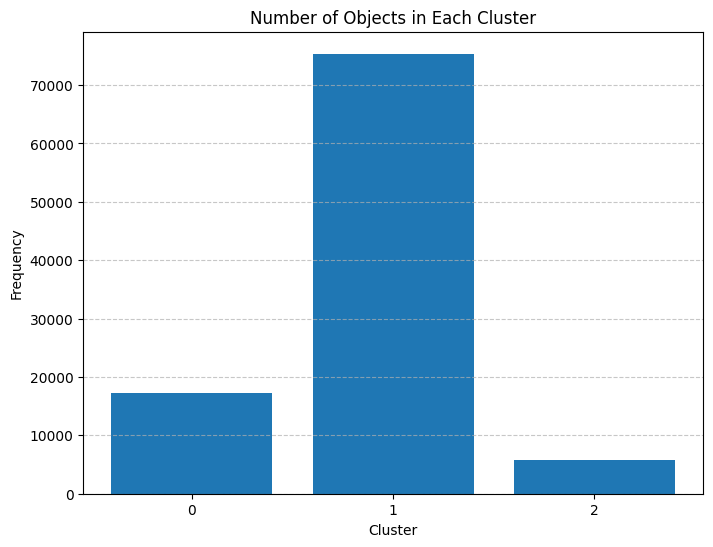

In [ ]:
import matplotlib.pyplot as plt

# Broj objekata u svakom klasteru
cluster_counts = df['Cluster'].value_counts()

# Nacrtaj histogram
plt.figure(figsize=(8, 6))
plt.bar(cluster_counts.index, cluster_counts.values)
plt.title('Number of Objects in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Frequency')
plt.xticks(cluster_counts.index)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Log-vjerovatnoća
log_likelihood = gmm.score(data_pca) * len(data_pca)
print(f"Log-Likelihood: {log_likelihood}")

Log-Likelihood: -2716415.8979211124


In [ ]:
# AIC vrijednost
aic = gmm.aic(data_pca)
print(f"AIC: {aic}")

AIC: 5434629.795842225


In [ ]:
# AIC vrijednost
bic = gmm.bic(data_pca)
print(f"BIC: {bic}")

BIC: 5443167.762628656


In [ ]:
print(gmm.n_iter_)

16


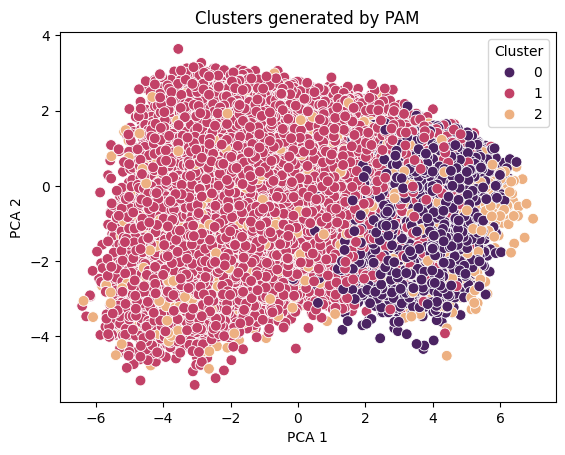

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x=data_pca[:, 0], y=data_pca[:, 1], hue=cluster_labels, palette='flare_r', s=60)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Clusters generated by PAM')
plt.legend(title='Cluster')
plt.show()

In [ ]:
optimal_clusters = 4
gmm = GaussianMixture(n_components=optimal_clusters, random_state=42)
gmm.fit(data_pca)

# Assign each data point to a cluster
cluster_labels = gmm.predict(data_pca)

df['Cluster'] = cluster_labels

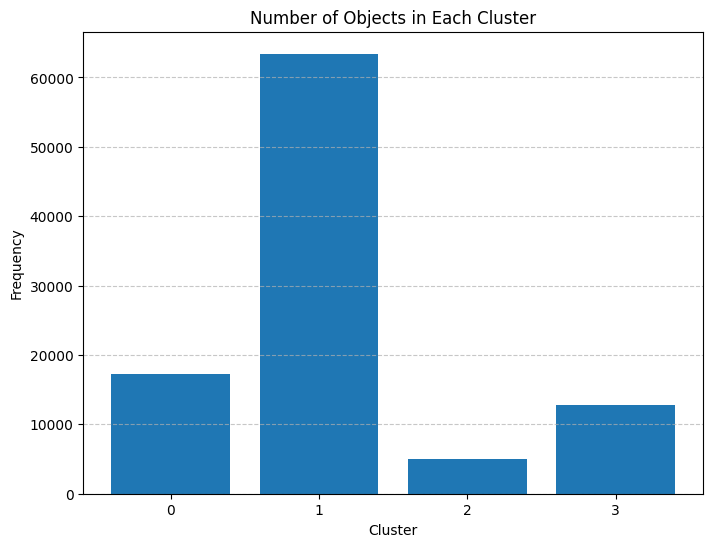

In [ ]:
import matplotlib.pyplot as plt

# Broj objekata u svakom klasteru
cluster_counts = df['Cluster'].value_counts()

# Nacrtaj histogram
plt.figure(figsize=(8, 6))
plt.bar(cluster_counts.index, cluster_counts.values)
plt.title('Number of Objects in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Frequency')
plt.xticks(cluster_counts.index)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Log-vjerovatnoća
log_likelihood = gmm.score(data_pca) * len(data_pca)
print(f"Log-Likelihood: {log_likelihood}")

Log-Likelihood: -2280941.051748079


In [ ]:
# AIC vrijednost
aic = gmm.aic(data_pca)
print(f"AIC: {aic}")

AIC: 4564280.103496158


In [ ]:
# BIC vrijednost
bic = gmm.bic(data_pca)
print(f"BIC: {bic}")

BIC: 4575667.224938795


In [ ]:
print(gmm.n_iter_)

17


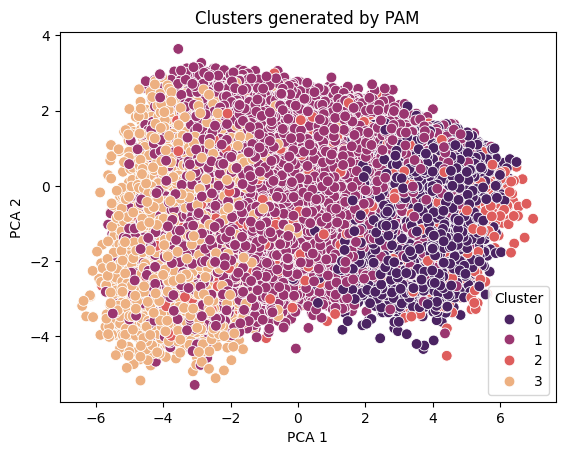

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x=data_pca[:, 0], y=data_pca[:, 1], hue=cluster_labels, palette='flare_r', s=60)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Clusters generated by PAM')
plt.legend(title='Cluster')
plt.show()

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.50)
data_pca = pca.fit_transform(data)

In [ ]:
print(f"Broj zadržanih komponenti: {pca.n_components_}")

Broj zadržanih komponenti: 9


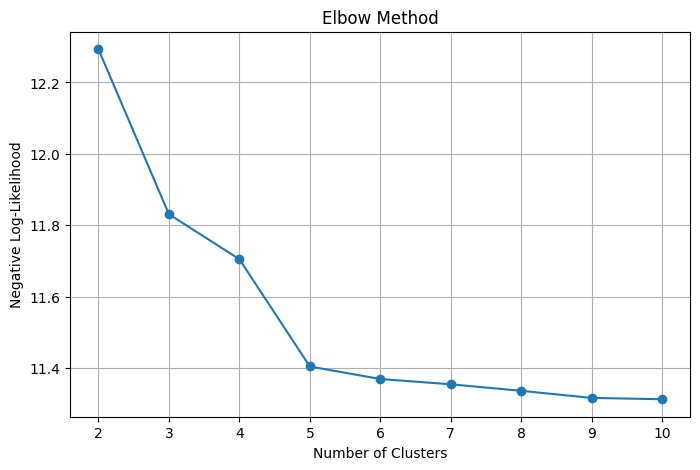

In [ ]:
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

# Range of cluster numbers to test
k_values = range(2, 11)

# Negative log-likelihood as a measure of cost
log_likelihoods = []
for k in k_values:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(data_pca)
    log_likelihoods.append(-gmm.lower_bound_)

# Plot the Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(k_values, log_likelihoods, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Negative Log-Likelihood')
plt.grid()
plt.show()

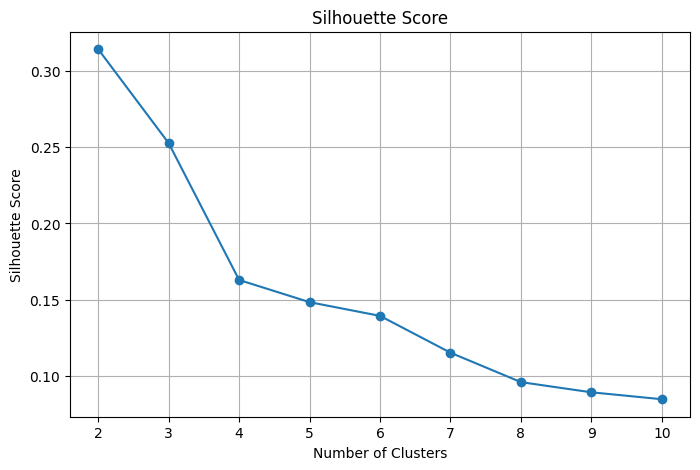

In [ ]:
from sklearn.metrics import silhouette_score

# Silhouette scores for different numbers of clusters
silhouette_scores = []

for k in range(2, 11):  # Start from 2 since silhouette is undefined for 1 cluster
    gmm = GaussianMixture(n_components=k, random_state=42)
    labels = gmm.fit_predict(data_pca)
    score = silhouette_score(data_pca, labels)
    silhouette_scores.append(score)

# Plot the Silhouette Score
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Score')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.grid()
plt.show()

In [ ]:
optimal_clusters = 2
gmm = GaussianMixture(n_components=optimal_clusters, random_state=42)
gmm.fit(data_pca)

# Assign each data point to a cluster
cluster_labels = gmm.predict(data_pca)

df['Cluster'] = cluster_labels

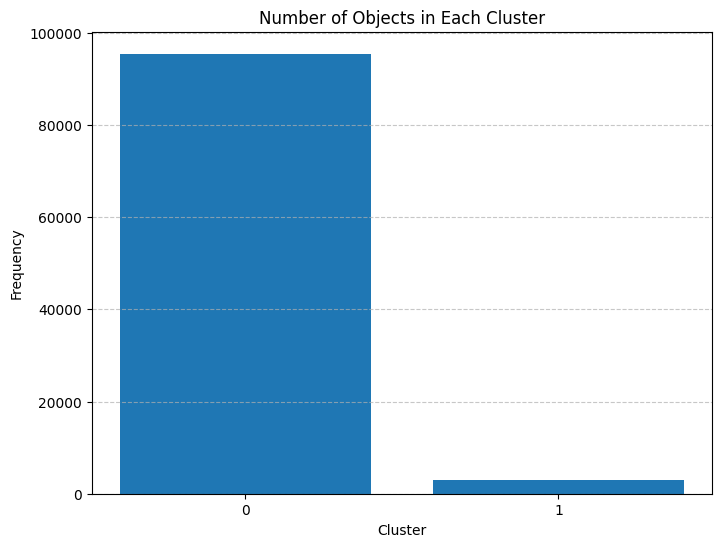

In [ ]:
import matplotlib.pyplot as plt

# Broj objekata u svakom klasteru
cluster_counts = df['Cluster'].value_counts()

# Nacrtaj histogram
plt.figure(figsize=(8, 6))
plt.bar(cluster_counts.index, cluster_counts.values)
plt.title('Number of Objects in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Frequency')
plt.xticks(cluster_counts.index)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Log-vjerovatnoća
log_likelihood = gmm.score(data_pca) * len(data_pca)
print(f"Log-Likelihood: {log_likelihood}")

Log-Likelihood: -1210113.991598675


In [ ]:
# AIC vrijednost
aic = gmm.aic(data_pca)
print(f"AIC: {aic}")

AIC: 2420445.98319735


In [ ]:
# BIC vrijednost
bic = gmm.bic(data_pca)
print(f"BIC: {bic}")

BIC: 2421481.1760557718


In [ ]:
print(gmm.n_iter_)

15


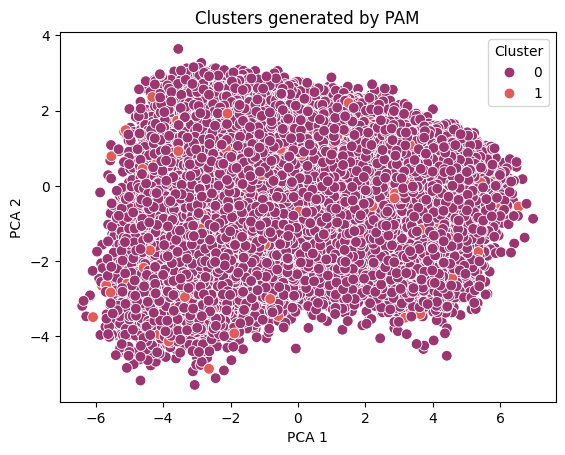

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x=data_pca[:, 0], y=data_pca[:, 1], hue=cluster_labels, palette='flare_r', s=60)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Clusters generated by PAM')
plt.legend(title='Cluster')
plt.show()

In [ ]:
optimal_clusters = 5
gmm = GaussianMixture(n_components=optimal_clusters, random_state=42)
gmm.fit(data_pca)

# Assign each data point to a cluster
cluster_labels = gmm.predict(data_pca)

df['Cluster'] = cluster_labels

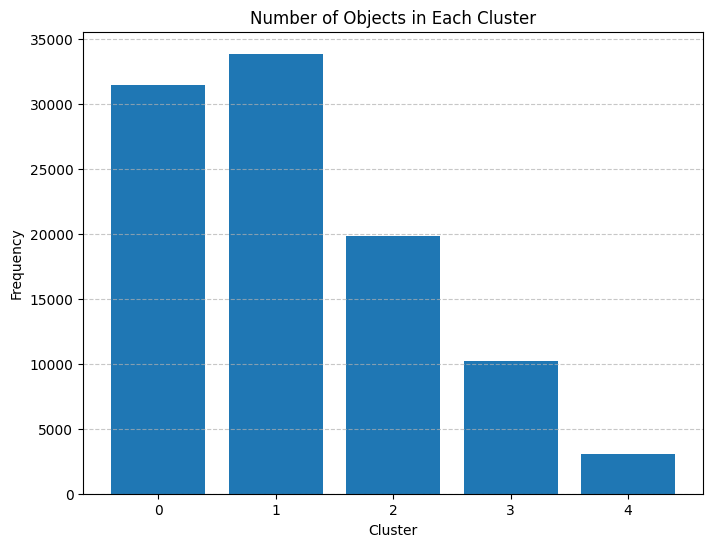

In [ ]:
import matplotlib.pyplot as plt

# Broj objekata u svakom klasteru
cluster_counts = df['Cluster'].value_counts()

# Nacrtaj histogram
plt.figure(figsize=(8, 6))
plt.bar(cluster_counts.index, cluster_counts.values)
plt.title('Number of Objects in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Frequency')
plt.xticks(cluster_counts.index)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Log-vjerovatnoća
log_likelihood = gmm.score(data_pca) * len(data_pca)
print(f"Log-Likelihood: {log_likelihood}")

Log-Likelihood: -1122541.6740565738


In [ ]:
# AIC vrijednost
aic = gmm.aic(data_pca)
print(f"AIC: {aic}")

AIC: 2245631.3481131475


In [ ]:
# BIC vrijednost
bic = gmm.bic(data_pca)
print(f"BIC: {bic}")

BIC: 2248233.5760324826


In [ ]:
print(gmm.n_iter_)

17


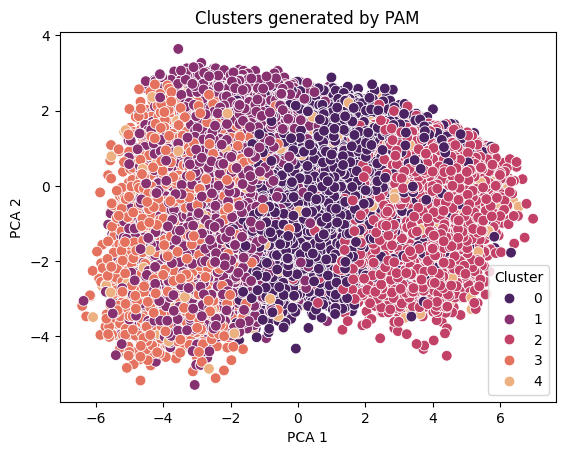

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x=data_pca[:, 0], y=data_pca[:, 1], hue=cluster_labels, palette='flare_r', s=60)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Clusters generated by PAM')
plt.legend(title='Cluster')
plt.show()